In [2]:
%load_ext autoreload
%autoreload 2
import os, sys
import numpy as np
import pandas as pd
import scanpy as sc
import PINN
import torch

os.chdir("/ssd/users/Wergillius/Project/PINN_dynamics")

import warnings
warnings.filterwarnings("ignore")

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# load adata and check v genes

In [4]:
meahr_monocle = sc.read_h5ad("data/meahr_monocle.h5ad")

In [14]:
meahr_monocle = meahr_monocle[meahr_monocle.obs.leiden != '9']

# palantir gene trends

In [5]:
import palantir

In [118]:
masks = palantir.presults.select_branch_cells(meahr_monocle, q=.001, eps=.02)

In [119]:
masks

array([[False,  True],
       [False, False],
       [False, False],
       ...,
       [False,  True],
       [False, False],
       [False,  True]])

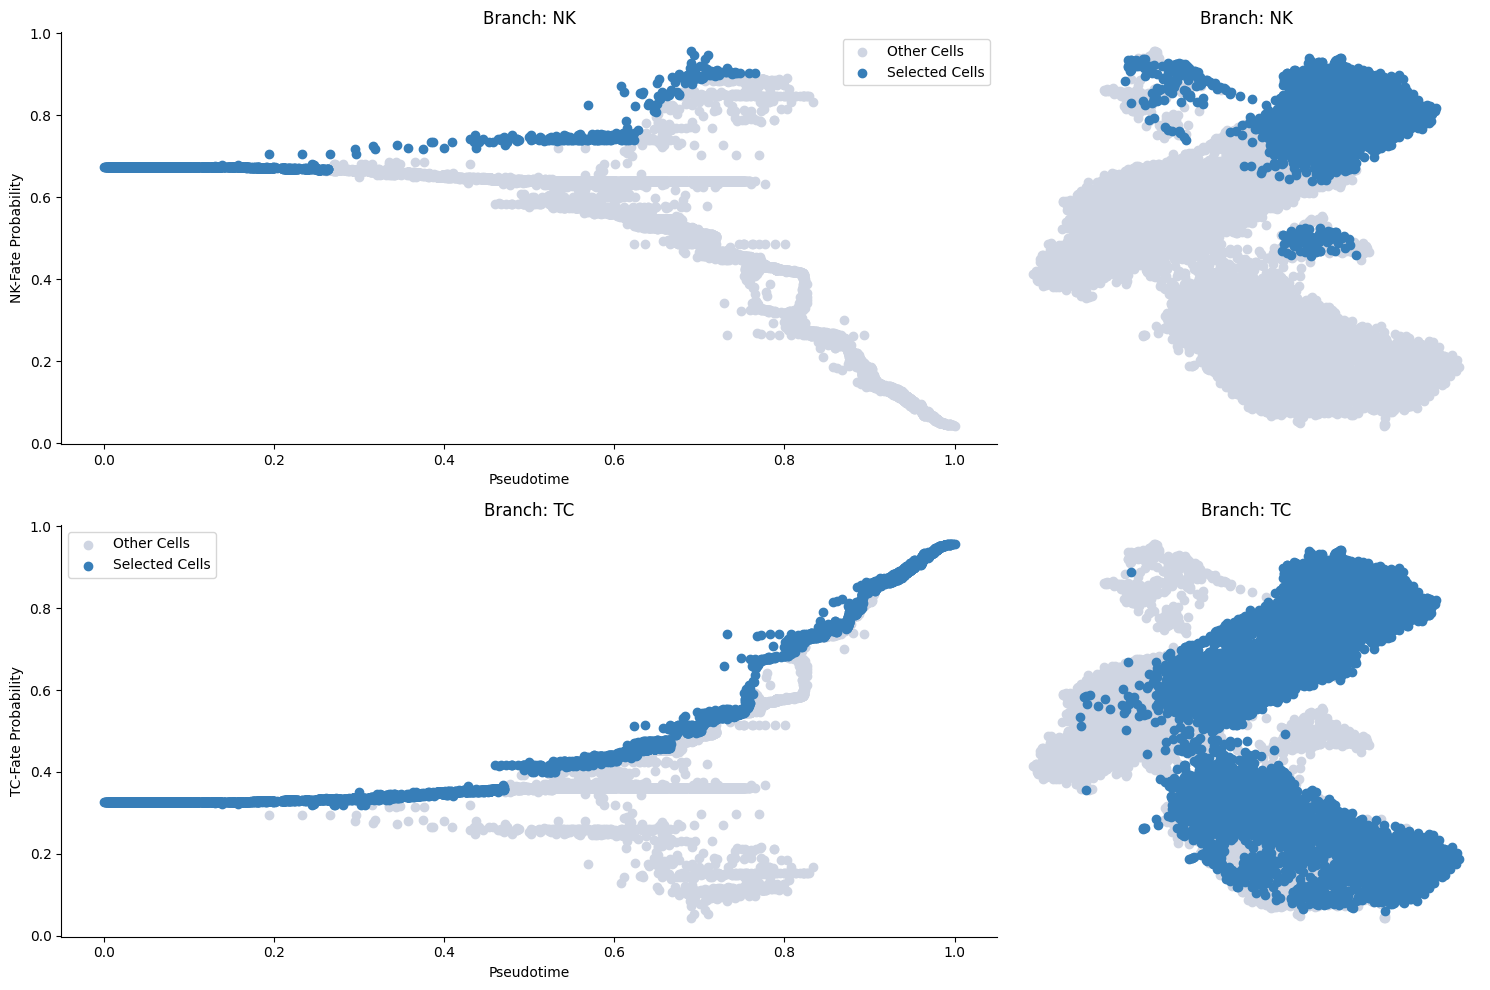

In [120]:
palantir.plot.plot_branch_selection(meahr_monocle)
plt.show()

[2025-02-04 21:12:17,782] [INFO    ] Using sparse Gaussian Process since n_landmarks (50) < n_samples (5,729) and rank = 1.0.
[2025-02-04 21:12:17,784] [INFO    ] Using covariance function Matern52(ls=1.1975090980529786).
[2025-02-04 21:12:17,815] [INFO    ] Computing 50 landmarks with k-means clustering.


<Axes: title={'center': 'Branch: TC'}>

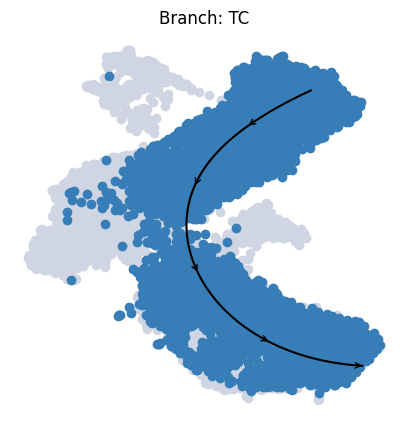

In [121]:
palantir.plot.plot_trajectory(meahr_monocle, "TC")

In [122]:
gene_trends = palantir.presults.compute_gene_trends(
    meahr_monocle,
    expression_key="MAGIC_imputed_data",
)

NK
[2025-02-04 21:12:28,412] [INFO    ] Using sparse Gaussian Process since n_landmarks (500) < n_samples (2,062) and rank = 1.0.
[2025-02-04 21:12:28,413] [INFO    ] Using covariance function Matern52(ls=1.0).


TC
[2025-02-04 21:12:29,556] [INFO    ] Using sparse Gaussian Process since n_landmarks (500) < n_samples (5,729) and rank = 1.0.
[2025-02-04 21:12:29,556] [INFO    ] Using covariance function Matern52(ls=1.0).


In [132]:
more_genes = meahr_monocle.var_names
clusters = palantir.presults.cluster_gene_trends(meahr_monocle, "TC", more_genes, n_neighbors=50)

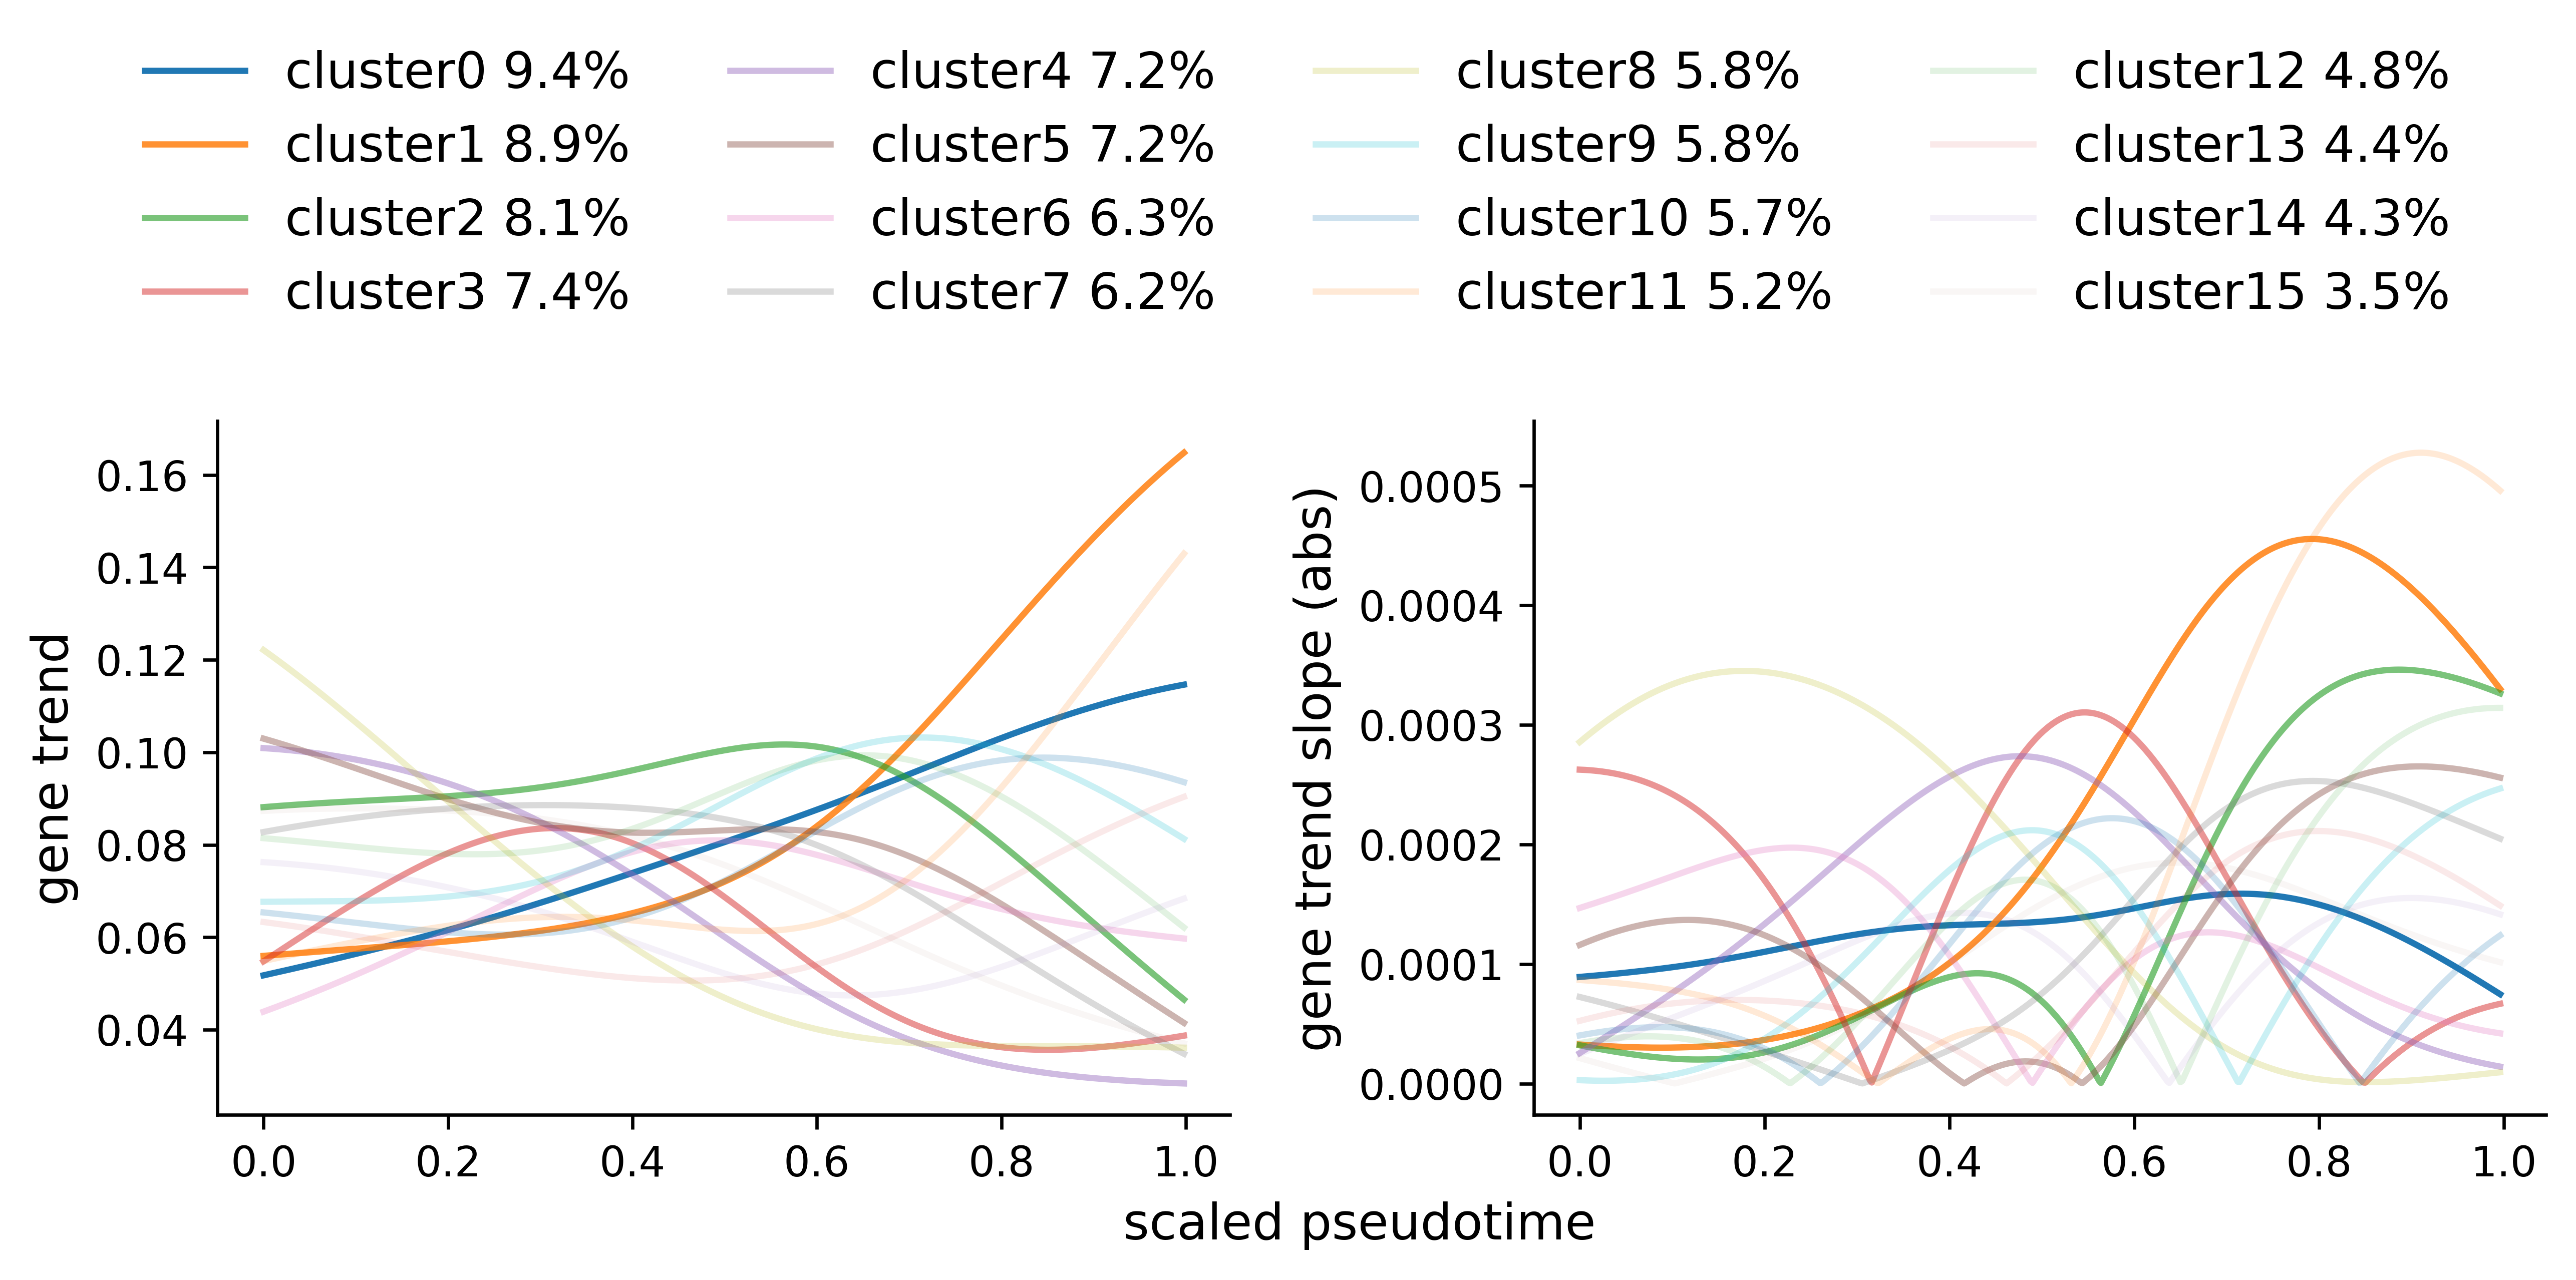

In [161]:
clusters = meahr_monocle.var['gene_trends_clusters']
cluster_labels = meahr_monocle.var['gene_trends_clusters'].cat.categories
trends = meahr_monocle.varm['gene_trends_TC']

n_genes = clusters.shape[0]
n_gene_cluster = clusters.value_counts()

alphas = n_gene_cluster / n_genes 

fig, axs = plt.subplots(1,2,figsize=(10,3), dpi=600, gridspec_kw={'wspace':0.3})

for i, c in enumerate(cluster_labels):
    cluster_trends = trends.loc[clusters.index[clusters == c], :]
    means = cluster_trends.mean()
    std = cluster_trends.std()


    alpha = alphas[c]

    # means /= means.max()
    # means /= std

    slope = np.abs(np.diff(means))
    # slope = 

    axs[0].plot(means, label = 'cluster{} {:.1f}%'.format(c,alpha*100), alpha=alpha**3*1200)
    axs[1].plot(slope, alpha=alpha**3*1200)
# plt.legend()
axs[0].set_xticks(np.linspace(0,len(means),6));
axs[0].set_xticklabels(np.around(np.linspace(0,1,6),2).astype(str));
axs[1].set_xticks(np.linspace(0,len(means),6));
axs[1].set_xticklabels(np.around(np.linspace(0,1,6),2).astype(str));


axs[0].set_xlabel("  "*40+'scaled pseudotime', fontsize=12)
axs[0].set_ylabel("gene trend", fontsize=12)
axs[1].set_ylabel("gene trend slope (abs)", fontsize=12)


axs[0].legend(ncol=4, bbox_to_anchor=[1.45, 1.2, 0.8, 0.4], fontsize=12, frameon=False)

In [135]:
alpha

0.03482729089351984

In [136]:
clusters.shape

(7006,)

In [138]:
(n_gene_cluster / n_genes)**3*1200

gene_trends_clusters
0     0.994142
1     0.847861
2     0.632732
3     0.490660
4     0.446748
5     0.438818
6     0.299286
7     0.283292
8     0.235263
9     0.228395
10    0.218345
11    0.169687
12    0.133555
13    0.099985
14    0.094218
15    0.050692
Name: count, dtype: float64

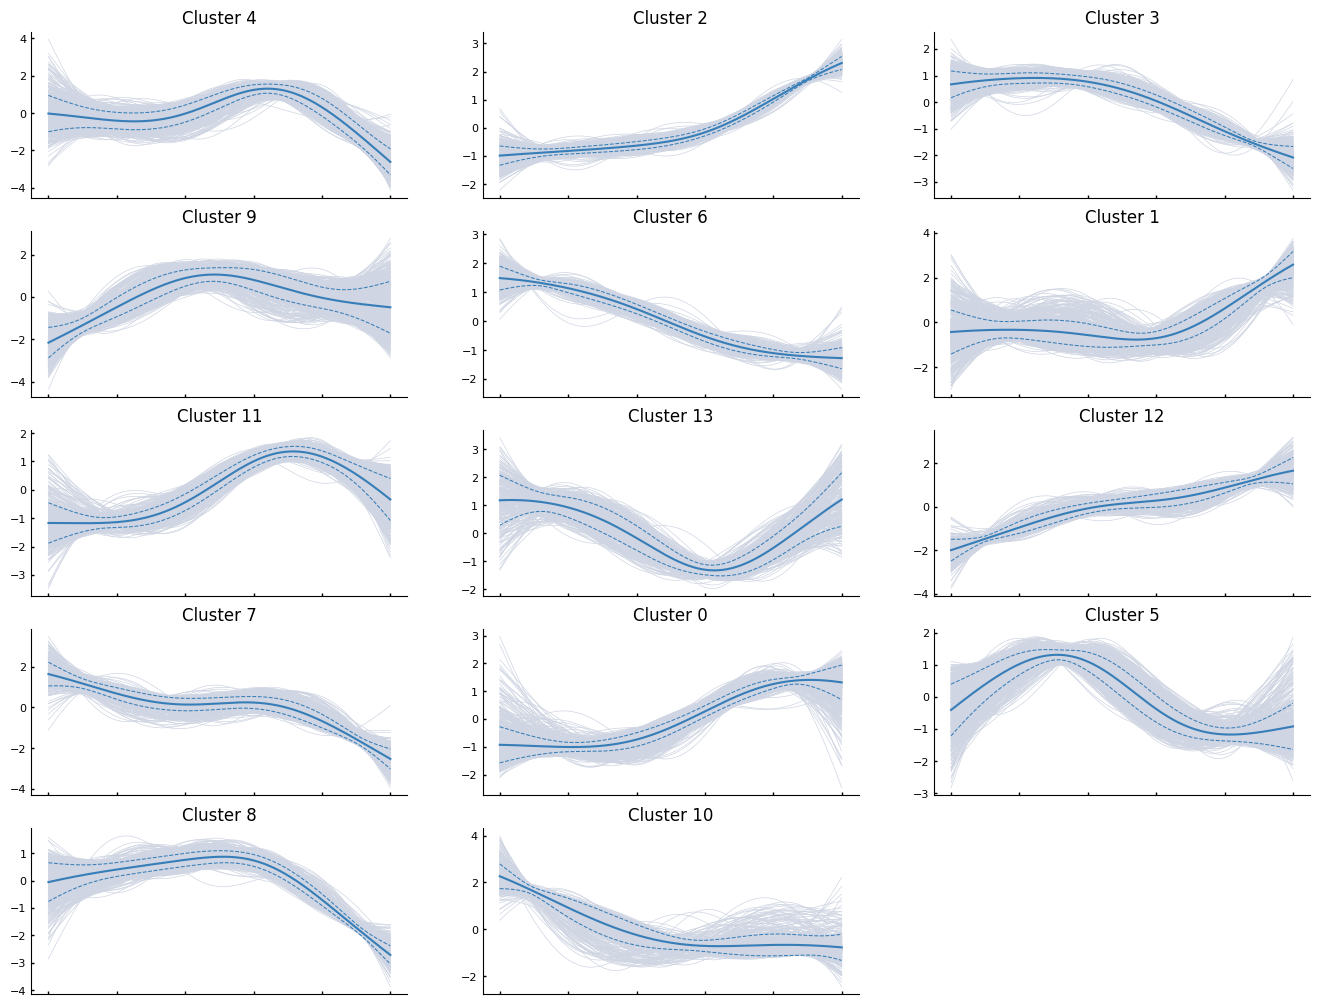

In [127]:
fig = palantir.plot.plot_gene_trend_clusters(meahr_monocle, "TC")
plt.show()

In [163]:
trends

,0.0,0.002004008016032064,0.004008016032064128,0.0060120240480961915,0.008016032064128256,0.01002004008016032,0.012024048096192383,0.014028056112224447,0.01603206412825651,0.018036072144288574,...,0.9819639278557113,0.9839679358717434,0.9859719438877754,0.9879759519038075,0.9899799599198396,0.9919839679358716,0.9939879759519037,0.9959919839679358,0.9979959919839678,1.0
Gene,,,,,,,,,,,,,,,,,,,,,
0610009B22Rik,0.189731,0.189644,0.189556,0.189467,0.189377,0.189286,0.189193,0.189100,0.189005,0.188909,...,0.107873,0.107712,0.107549,0.107386,0.107223,0.107058,0.106894,0.106728,0.106562,0.106396
0610009L18Rik,0.025810,0.025769,0.025727,0.025685,0.025643,0.025600,0.025557,0.025514,0.025470,0.025426,...,0.001390,0.001411,0.001432,0.001454,0.001475,0.001496,0.001517,0.001538,0.001559,0.001580
0610009O20Rik,0.076749,0.076737,0.076725,0.076713,0.076701,0.076688,0.076676,0.076664,0.076651,0.076638,...,0.101325,0.101400,0.101473,0.101545,0.101615,0.101685,0.101753,0.101819,0.101885,0.101949
0610010F05Rik,0.200145,0.200361,0.200575,0.200788,0.200999,0.201208,0.201415,0.201621,0.201824,0.202026,...,0.086123,0.085572,0.085022,0.084472,0.083923,0.083373,0.082824,0.082274,0.081725,0.081177
0610030E20Rik,0.102716,0.102579,0.102441,0.102303,0.102165,0.102026,0.101887,0.101747,0.101607,0.101467,...,0.180579,0.180734,0.180888,0.181040,0.181191,0.181339,0.181485,0.181629,0.181772,0.181912
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Zxdc,0.020268,0.020268,0.020268,0.020268,0.020267,0.020266,0.020264,0.020262,0.020260,0.020257,...,0.027107,0.027182,0.027257,0.027331,0.027406,0.027480,0.027554,0.027628,0.027702,0.027775
Zyg11b,0.090174,0.090222,0.090271,0.090318,0.090365,0.090411,0.090456,0.090500,0.090544,0.090586,...,0.172781,0.173096,0.173411,0.173723,0.174035,0.174345,0.174653,0.174960,0.175265,0.175569
Zzef1,0.044854,0.045062,0.045270,0.045479,0.045687,0.045895,0.046103,0.046310,0.046518,0.046726,...,0.116417,0.116602,0.116787,0.116970,0.117152,0.117334,0.117514,0.117693,0.117872,0.118049


In [162]:
clusters

Gene
0610009B22Rik     4
0610009L18Rik     8
0610009O20Rik    13
0610010F05Rik    15
0610030E20Rik     1
                 ..
Zxdc             13
Zyg11b            1
Zzef1             0
Zzz3              6
a                 1
Name: gene_trends_clusters, Length: 7006, dtype: category
Categories (16, object): ['0', '1', '2', '3', ..., '12', '13', '14', '15']